In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Erosion function

In [7]:
def erosion(image, structuring_element):
    eroded_image = image.copy()
    structuring_element = structuring_element*255
    offset = structuring_element.shape[0]//2
    height, width = image.shape
    for i in range(height):
        for j in range(width):
            fit = True
            for x in range(-offset, offset):
                for y in range(-offset, offset):
                    if (i+x>=0 and i+x<height and j+y>=0 and j+y<width):
                        if structuring_element[x+offset][y+offset]>0 and structuring_element[x+offset][y+offset] != image[i+x][j+y]:
                            fit = False
                    elif structuring_element[x+offset][y+offset]>0:
                        fit = False
            if fit:
                eroded_image[i][j] = 255
            else:
                eroded_image[i][j] = 0
    return eroded_image

### Dilation function

In [10]:
def dilation(image, structuring_element):
    dilated_image = image.copy()
    structuring_element = structuring_element*255
    offset = structuring_element.shape[0]//2
    height, width = image.shape
    for i in range(height):
        for j in range(width):
            hit = False
            for x in range(-offset, offset):
                for y in range(-offset, offset):
                    if (i+x>=0 and i+x<height and j+y>=0 and j+y<width):
                        if structuring_element[x+offset][y+offset]>0 and structuring_element[x+offset][y+offset] == image[i+x][j+y]:
                            hit = True

            if hit:
                dilated_image[i][j] = 255
            else:
                dilated_image[i][j] = 0
                
    return dilated_image

### Creating structuring element

In [4]:
size = 3
structuring_element = np.ones((size, size))

### Loading original image

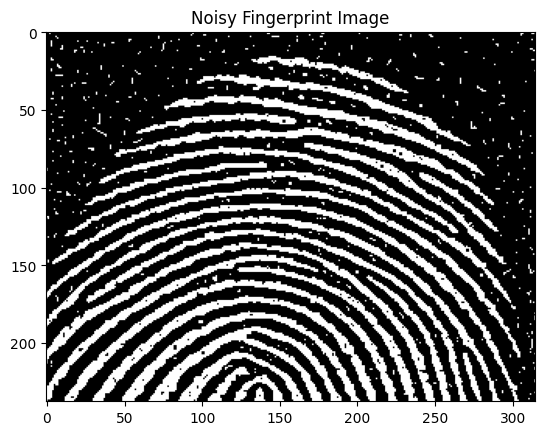

In [5]:
noisy_fingerprint = cv2.imread("Noisy Fingerprint 315x238.tif", 0)
plt.imshow(noisy_fingerprint, cmap = "gray")
plt.title("Noisy Fingerprint Image")
plt.show()

### Applying Erosion

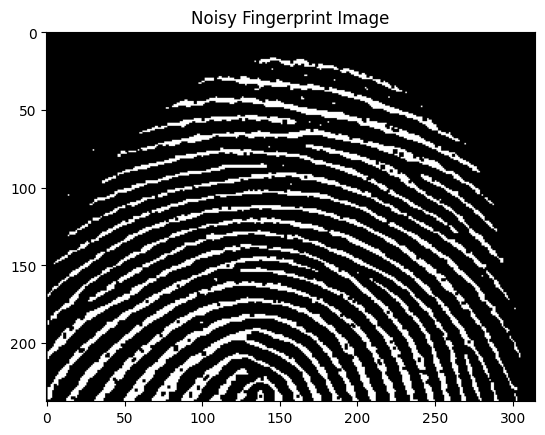

In [9]:
eroded_image = erosion(noisy_fingerprint, structuring_element)
plt.imshow(eroded_image, cmap = "gray")
plt.title("Noisy Fingerprint Image")
plt.show()

### Applying Dilation

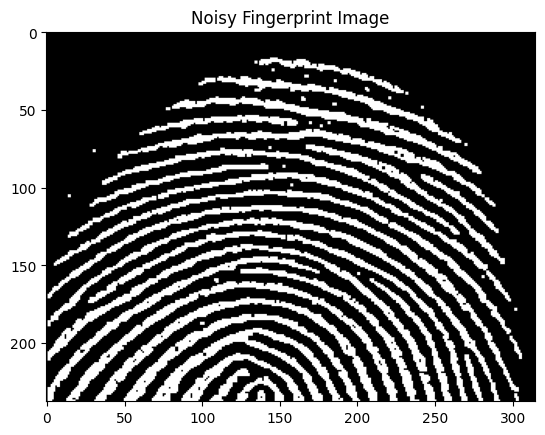

In [13]:
dilated_image = dilation(eroded_image, structuring_element)
plt.imshow(dilated_image, cmap = "gray")
plt.title("Noisy Fingerprint Image")
plt.show()